# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Made Dinda Radityaswari
- **Email:** radityaswaridinda@gmail.com
- **ID Dicoding:** Made Dinda Radityaswari

## Menentukan Pertanyaan Bisnis

- Bagaimana pola jumlah penyewaan sepeda berdasarkan jam dalam satu hari pada tahun 2011–2012 dan kapan waktu dengan tingkat penyewaan tertinggi terjadi?

- Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda per hari selama periode 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Gathering data adalah proses mengumpulkan data yang digunakan untuk menjawab pertanyaan bisnis yang terdiri dari 2 dataset yaitu dataset hour dan dataset day.

In [2]:
df_hour = pd.read_csv("data/hour.csv")
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df_day = pd.read_csv("data/day.csv")
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset terdiri dari dua bagian: data per jam (hour) dan data per hari (day).
- Di masing-masing dari kedua dataset terdapat kolom instan, dteday, season, yr, mnth, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, casual, registered, dan cnt, tetapi pada dataset hour terdapat kolom hr yang tidak dimiliki oleh dataset day. Semua datasetnya tidak ada yang kategorikal karena semua sudah diubah menjadi bentuk numerik.
- kolom instant adalah indeks data (nomor urutan).
- kolom dteday adalah tanggal.
- kolom season adalah musim dengan penjelasan masing-masing isinya sebagai berikut: 1 = semi (spring), 2 = panas (summer), 3 = gugur (fall), dan 4 = dingin (winter).
- kolom yr adalah tahun dengan penjelasan masing-masing isinya sebagai berikut: 0 = 2011 dan 1 dan 2012.
- kolom mnth adalah bulan mulai dari 1 sampai 12.
- kolom hr adalah jam mulai dari 0 sampai 23.
- kolom holiday adalah apakah hari tersebut hari libur atau tidak.
- kolom weekday adalah hari dalam seminggu.
- kolom workingday terdiri dari sebagai berikut: 1 = hari kerja (bukan weekend/libur) dan 0 = bukan hari kerja (weekend/libur).
- kolom weathersit adalah kondisi cuaca dengan penjelasan masing-masing isinya sebagai berikut: 1 = cerah, sedikit berawan, sebagian berawan; 2 = berkabut + berawan; 3 = hujan ringan / salju ringan + badai; dan 4 = hujan lebat + es + badai + kabut.
- kolom temp adalah suhu yang sudah dinormalisasi dalam Celsius yang dihitung dengan rumus: (t - t_min) / (t_max - t_min) dengan t_min = -8 dan t_max = 39.
- kolom atemp adalah suhu yang dirasakan (feels like) yang sudah dinormalisasi dengan t_min = -16 dan t_max = 50.
- kolom hum adalah kelembapan yang sudah dinormalisasi dengan dibagi 100.
- kolom windspeed adalah kecepatan angin yang udah dinormalisasi dengan dibagi 67.
- kolom casual adalah jumlah pengguna tidak terdaftar.
- kolom registered adalah jumlah pengguna terdaftar.
- kolom cnt adalah total penyewaan sepeda (casual + registered).

### Assessing Data

Assessing data adalah proses untuk menilai kualitas dan struktur dari dataset yang digunakan.

#### Informasi df_hour

1. Memeriksa tipe data dari tiap kolom yang terdapat di dataset hour.

In [4]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


2. Memeriksa apakah terdapat missing value di tiap kolom pada dataset hour.

In [5]:
df_hour.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

3. Memeriksa apakah terdapat data yang duplikat di tiap kolom ada dataset hour.

In [6]:
df_hour.duplicated().sum()

np.int64(0)

4. Memeriksa parameter statistik dari kolom numerik yang terdapat di dataset hour.

In [7]:
df_hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight df_hour:**
- Jumlah data sebanyak 17.379 dan tidak ada missing value maupun data duplikat.
- Rata-rata jumlah penyewaan sepeda per jam (cnt) adalah sekitar 189 unit, dengan nilai maksimum mencapai 977 penyewaan, yang menunjukkan adanya lonjakan penggunaan pada waktu tertentu dalam sehari.
- Berdasarkan  kolom hr, distribusi data menunjukkan bahwa median berada di pukul 12.00, sementara kuartil atas (75%) berada di sekitar pukul 18.00, yang mengindikasikan bahwa aktivitas penyewaan cenderung meningkat dari siang hingga sore hari.
- Berdasarkan kolom weathersit memiliki rata-rata sebesar 1.42, yang berarti sebagian besar kondisi cuaca berada pada kategori cerah hingga sebagian berawan.
- Terdapat tipe data yang kurang sesuai, yaitu dteday yang masih bertipe object, sehingga perlu dilakukan konversi ke format datetime agar analisis berbasis waktu dapat lebih mudah dipahami.
- Pada kolom season, yr, mnth, holiday, weekday, workingday, dan weathersit yang sudah diubah ke bentuk numerik perlu dilakukan konversi ke bentuk kategorikal.
- Pada kolom temp, atemp, hum, dan windspeed yang sudah dinormalisasi perlu dilakukan denormalisasi menjadi angka yang asli.

#### Informasi df_day

1. Memeriksa tipe data dari tiap kolom yang terdapat di dataset day.

In [8]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


2. Memeriksa apakah terdapat missing value di tiap kolom pada dataset day.

In [9]:
df_day.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

3. Memeriksa apakah terdapat data yang duplikat di tiap kolom ada dataset day.

In [10]:
df_day.duplicated().sum()

np.int64(0)

4. Memeriksa parameter statistik dari kolom numerik yang terdapat di dataset day.

In [11]:
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight df_day:**
- Jumlah data sebanyak 731 dan tidak ada missing value maupun data duplikat.
- Rata-rata jumlah penyewaan sepeda per hari (cnt) adalah sekitar 4.504 unit, dengan nilai maksimum mencapai 8.714 penyewaan, yang menunjukkan adanya variasi permintaan yang cukup besar antar hari.
- Berdasarkan kolom weathersit, rata-rata sebesar 1.39, yang berarti sebagian besar kondisi cuaca berada pada kategori cerah hingga sebagian berawan ringan.
- Terdapat tipe data yang kurang sesuai, yaitu dteday yang masih bertipe object, sehingga perlu dilakukan konversi ke format datetime agar analisis berbasis waktu dapat lebih mudah dipahami.
- Pada kolom season, yr, mnth, holiday, weekday, workingday, dan weathersit yang sudah diubah ke bentuk numerik perlu dilakukan konversi ke bentuk kategorikal.
- Pada kolom temp, atemp, hum, dan windspeed yang sudah dinormalisasi perlu dilakukan denormalisasi menjadi angka yang asli.

### Cleaning Data

Cleaning data adalah proses untuk membersihkan data dari masalah yang ditemukan di proses sebelumnya. 

#### Cleaning df_hour

1. Mengubah tipe data kolom dteday menjadi datetime.

In [12]:
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

2. Mengubah kolom season dari numerik menjadi kategorikal dengan perubahan sebagai berikut : 1 = spring, 2 = summer, 3 = fall, dan 4 = winter.

In [13]:
df_hour['season'] = df_hour['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


3. Mengubah kolom yr dengan perubahan sebagai berikut : 0 = 2011 dan 1 = 2012.

In [14]:
df_hour['yr'] = df_hour['yr'].map({
    0: '2011', 1: '2012'
})
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


4. Mengubah kolom mnth dari numerik menjadi kategorikal dengan perubahan sebagai berikut : 1 = January, 2 = February, 3 = March, 4 = April, 5 = May, 6 = June, 7 = July, 8 = August, 9 = September, 10 = October, 11 = November, dan 12 = December.

In [15]:
df_hour['mnth']= df_hour['mnth'].map({
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'
})
df_hour.head()   

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


5. Mengubah kolom holiday dengan perubahan sebagai berikut : 0 = no dan 1 = yes.

In [16]:
df_hour['holiday'] = df_hour['holiday'].map({
    0: 'No', 1: 'Yes'})
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,No,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,No,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,No,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,No,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,No,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


6. Mengubah kolom weekday dari numerik menjadi kategorikal dengan perubahan sebagai berikut : 0 = Sunday, 1 = Monday, 2 = Tuesday, 3 = Wednesday, 4 = Thursday, 5 = Friday, dan 6 = Saturday.

In [17]:
df_hour['weekday'] = df_hour['weekday'].map({
    0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'
})
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,No,Saturday,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,No,Saturday,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,No,Saturday,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,No,Saturday,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,No,Saturday,0,1,0.24,0.2879,0.75,0.0,0,1,1


7. Mengubah kolom workingday dari numerik menjadi kategorikal dengan perubahan sebagai berikut : 0 = Weekend/Holiday dan 1 = Working Day.

In [18]:
df_hour['workingday'] = df_hour['workingday'].map({
    0: 'Weekend/Holiday', 1: 'Working Day'
})
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,No,Saturday,Weekend/Holiday,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,No,Saturday,Weekend/Holiday,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,No,Saturday,Weekend/Holiday,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,No,Saturday,Weekend/Holiday,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,No,Saturday,Weekend/Holiday,1,0.24,0.2879,0.75,0.0,0,1,1


8. Mengubah kolom weathersit dari numerik menjadi kategorikal dengan perubahan sebagai berikut : 1 = Clear/Few clouds/Partly cloudy/Partly cloudy; 2 = Mist Cloudy/Mist Broken clouds/Mist Few clouds/Mist; 3 = Light Snow/Light Rain Thunderstorm Scattered clouds/Light Rain Scattered clouds; dan 4 = Heavy Rain Ice Pallets Thunderstorm Mist/Snow Fog.

In [19]:
df_hour['weathersit'] = df_hour['weathersit'].map({
    1: 'Clear/Few clouds/Partly cloudy/Partly cloudy',
    2: 'Mist Cloudy/Mist Broken clouds/Mist Few clouds/Mist',
    3: 'Light Snow/Light Rain Thunderstorm Scattered clouds/Light Rain Scattered clouds',
    4: 'Heavy Rain Ice Pallets Thunderstorm Mist/Snow Fog'
})
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,0.24,0.2879,0.75,0.0,0,1,1


9. Mengubah kolom temp dengan mengembalikan ke nilai aslinya dengan rumus : (nilai normalisasi * (t max - t min)) + t min.

In [20]:
df_hour['temp'] = df_hour['temp'] * (39 - (-8)) + (-8)
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,2.34,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,2.34,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,0.2879,0.75,0.0,0,1,1


10. Mengubah kolom atemp dengan mengembalikan ke nilai aslinya dengan rumus : (nilai normalisasi * (t max - t min)) + t min.

In [21]:
df_hour['atemp'] = df_hour['atemp'] * (50 - (-16)) + (-16)
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,2.34,1.9982,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,2.34,1.9982,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,0.75,0.0,0,1,1


11. Mengubah kolom hum dengan mengembalikan ke nilai aslinya dengan mengalikannya dengan 100.

In [22]:
df_hour['hum'] = df_hour['hum'] * 100
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,81.0,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,2.34,1.9982,80.0,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,2.34,1.9982,80.0,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,75.0,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,75.0,0.0,0,1,1


12. Mengubah kolom windspeed dengan mengembalikan ke nilai aslinya dengan mengalikannya dengan 67.

In [23]:
df_hour['windspeed']=df_hour['windspeed'] * 67
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,81.0,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,2.34,1.9982,80.0,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,2.34,1.9982,80.0,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,75.0,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,75.0,0.0,0,1,1


In [24]:
df_hour.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379,17379,17379.000000,17379,17379,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,2,12,NaN,2,7,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012,July,NaN,No,Saturday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,8734,1488,NaN,16879,2512,11865,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,11.546752,NaN,NaN,NaN,NaN,15.358397,15.401157,62.722884,12.736540,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,-7.060000,-16.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,7.980000,5.997800,48.000000,7.001500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,15.500000,15.996800,63.000000,12.998000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,23.020000,24.999200,78.000000,16.997900,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,39.000000,50.000000,100.000000,56.996900,367.000000,886.000000,977.000000


**Insight df hour:**
- Kolom tanggal berhasil dikonversi ke format datetime.
- Mengubah semua kolom yang sudah dinormalisasikan ke bentuk aslinya baik itu ke bentuk kategorikal maupun ke angka asli.

#### Cleaning df_day

1. Mengubah tipe data kolom dteday menjadi datetime.

In [25]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

2. Mengubah kolom season dari numerik menjadi kategorikal dengan perubahan sebagai berikut : 1 = spring, 2 = summer, 3 = fall, dan 4 = winter.

In [26]:
df_day['season'] = df_day['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


3. Mengubah kolom yr dengan perubahan sebagai berikut : 0 = 2011 dan 1 = 2012.

In [27]:
df_day['yr'] = df_day['yr'].map({
    0: '2011', 1: '2012'
})
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


4. Mengubah kolom mnth dari numerik menjadi kategorikal dengan perubahan sebagai berikut : 1 = January, 2 = February, 3 = March, 4 = April, 5 = May, 6 = June, 7 = July, 8 = August, 9 = September, 10 = October, 11 = November, dan 12 = December.

In [28]:
df_day['mnth']= df_day['mnth'].map({
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'
})
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,January,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,January,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,January,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,January,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


5. Mengubah kolom holiday dengan perubahan sebagai berikut : 0 = no dan 1 = yes.

In [29]:
df_day['holiday'] = df_day['holiday'].map({
    0: 'No', 1: 'Yes'})
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,No,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,January,No,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,January,No,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,January,No,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,January,No,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


6. Mengubah kolom weekday dari numerik menjadi kategorikal dengan perubahan sebagai berikut : 0 = Sunday, 1 = Monday, 2 = Tuesday, 3 = Wednesday, 4 = Thursday, 5 = Friday, dan 6 = Saturday.

In [30]:
df_day['weekday'] = df_day['weekday'].map({
    0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'
})
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,No,Saturday,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,January,No,Sunday,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,January,No,Monday,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,January,No,Tuesday,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,January,No,Wednesday,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


7. Mengubah kolom workingday dari numerik menjadi kategorikal dengan perubahan sebagai berikut : 0 = Weekend/Holiday dan 1 = Working Day.

In [31]:
df_day['workingday'] = df_day['workingday'].map({
    0: 'Weekend/Holiday', 1: 'Working Day'
})
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,No,Saturday,Weekend/Holiday,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,January,No,Sunday,Weekend/Holiday,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,January,No,Monday,Working Day,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,January,No,Tuesday,Working Day,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,January,No,Wednesday,Working Day,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


8. Mengubah kolom weathersit dari numerik menjadi kategorikal dengan perubahan sebagai berikut : 1 = Clear/Few clouds/Partly cloudy/Partly cloudy; 2 = Mist Cloudy/Mist Broken clouds/Mist Few clouds/Mist; 3 = Light Snow/Light Rain Thunderstorm Scattered clouds/Light Rain Scattered clouds; dan 4 = Heavy Rain Ice Pallets Thunderstorm Mist/Snow Fog.

In [32]:
df_day['weathersit'] = df_day['weathersit'].map({
    1: 'Clear/Few clouds/Partly cloudy/Partly cloudy',
    2: 'Mist Cloudy/Mist Broken clouds/Mist Few clouds/Mist',
    3: 'Light Snow/Light Rain Thunderstorm Scattered clouds/Light Rain Scattered clouds',
    4: 'Heavy Rain Ice Pallets Thunderstorm Mist/Snow Fog'
})
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,No,Saturday,Weekend/Holiday,Mist Cloudy/Mist Broken clouds/Mist Few clouds...,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,January,No,Sunday,Weekend/Holiday,Mist Cloudy/Mist Broken clouds/Mist Few clouds...,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,January,No,Monday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,January,No,Tuesday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,January,No,Wednesday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600


9. Mengubah kolom temp dengan mengembalikan ke nilai aslinya dengan rumus : (nilai normalisasi * (t max - t min)) + t min.

In [33]:
df_day['temp'] = df_day['temp'] * (39 - (-8)) + (-8)
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,No,Saturday,Weekend/Holiday,Mist Cloudy/Mist Broken clouds/Mist Few clouds...,8.175849,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,January,No,Sunday,Weekend/Holiday,Mist Cloudy/Mist Broken clouds/Mist Few clouds...,9.083466,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,January,No,Monday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,1.229108,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,January,No,Tuesday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,1.400000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,January,No,Wednesday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,2.666979,0.229270,0.436957,0.186900,82,1518,1600


10. Mengubah kolom atemp dengan mengembalikan ke nilai aslinya dengan rumus : (nilai normalisasi * (t max - t min)) + t min.

In [34]:
df_day['atemp'] = df_day['atemp'] * (50 - (-16)) + (-16)
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,No,Saturday,Weekend/Holiday,Mist Cloudy/Mist Broken clouds/Mist Few clouds...,8.175849,7.999250,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,January,No,Sunday,Weekend/Holiday,Mist Cloudy/Mist Broken clouds/Mist Few clouds...,9.083466,7.346774,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,January,No,Monday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,1.229108,-3.499270,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,January,No,Tuesday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,1.400000,-1.999948,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,January,No,Wednesday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,2.666979,-0.868180,0.436957,0.186900,82,1518,1600


11. Mengubah kolom hum dengan mengembalikan ke nilai aslinya dengan mengalikannya dengan 100.

In [35]:
df_day['hum'] = df_day['hum'] * 100
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,No,Saturday,Weekend/Holiday,Mist Cloudy/Mist Broken clouds/Mist Few clouds...,8.175849,7.999250,80.5833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,January,No,Sunday,Weekend/Holiday,Mist Cloudy/Mist Broken clouds/Mist Few clouds...,9.083466,7.346774,69.6087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,January,No,Monday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,1.229108,-3.499270,43.7273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,January,No,Tuesday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,1.400000,-1.999948,59.0435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,January,No,Wednesday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,2.666979,-0.868180,43.6957,0.186900,82,1518,1600


12. Mengubah kolom windspeed dengan mengembalikan ke nilai aslinya dengan mengalikannya dengan 67.

In [36]:
df_hour['windspeed']=df_hour['windspeed'] * 67
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,81.0,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,2.34,1.9982,80.0,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,2.34,1.9982,80.0,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,75.0,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,No,Saturday,Weekend/Holiday,Clear/Few clouds/Partly cloudy/Partly cloudy,3.28,3.0014,75.0,0.0,0,1,1


In [37]:
df_hour.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379,17379,17379.000000,17379,17379,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,2,12,NaN,2,7,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012,July,NaN,No,Saturday,Working Day,Clear/Few clouds/Partly cloudy/Partly cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,8734,1488,NaN,16879,2512,11865,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,11.546752,NaN,NaN,NaN,NaN,15.358397,15.401157,62.722884,853.348155,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,-7.060000,-16.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,7.980000,5.997800,48.000000,469.100500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,15.500000,15.996800,63.000000,870.866000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,23.020000,24.999200,78.000000,1138.859300,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,39.000000,50.000000,100.000000,3818.792300,367.000000,886.000000,977.000000


**Insight df day:**
- Kolom tanggal berhasil dikonversi ke format datetime.
- Mengubah semua kolom yang sudah dinormalisasikan ke bentuk aslinya baik itu ke bentuk kategorikal maupun ke angka asli.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis adalah proses untuk memperoleh insight dan menjawab pertanyaan bisnis.

### Explore df hour untuk pertanyaan bisnis 1 : Bagaimana pola jumlah penyewaan sepeda berdasarkan jam dalam satu hari pada tahun 2011–2012 dan kapan waktu dengan tingkat penyewaan tertinggi terjadi?

1. Menghitung rata-rata penyewaan untuk setiap jam.

In [38]:
hourly_pattern = df_hour.groupby('hr')['cnt'].mean().reset_index()

2. Mengurutkan rata-rata penyewaan dari yang tertinggi.

In [39]:
top_hours = hourly_pattern.sort_values(by='cnt', ascending=False)

3. Menampilkan 5 jam dengan rata-rata penyewaan tertinggi.

In [40]:
print("5 Jam dengan tingkat penyewaan tertinggi (Rata-rata):")
print(top_hours.head())

5 Jam dengan tingkat penyewaan tertinggi (Rata-rata):
    hr         cnt
17  17  461.452055
18  18  425.510989
8    8  359.011004
16  16  311.983562
19  19  311.523352


4. Melihat perbandingan pola antara hari kerja dan hari libur.

In [41]:
pattern_by_daytype = df_hour.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

print("\nContoh perbandingan rata-rata pada jam 5 sore (hr=17):")
print(pattern_by_daytype[pattern_by_daytype['hr'] == 17])


Contoh perbandingan rata-rata pada jam 5 sore (hr=17):
         workingday  hr         cnt
17  Weekend/Holiday  17  323.549784
41      Working Day  17  525.290581


**Insight df hour untuk pertanyaan bisnis 1:**
- Jam 17.00 adalah puncak penyewaan tertinggi, hal ini berarti aktivitas sore memberikan kontribusi terbesar untuk bisnis penyewaan sepeda.
- 5 jam dengan tingkat penyewaan tertinggi mulai dari jam 8 dan jam 16.00 hingga jam 19.00 yang berarti penyewaan sepeda terjadi pada jam berangkat dan pulang kantor.
- Contoh perbandingan pola antara hari kerja dan hari libur pada jam 17.00 adalah pada hari kerja rata-rata penyewaannya jauh lebih tinggi daripada rata-rata gabungan hari kerja dan hari libur.

### Explore df day untuk pertanyaan bisnis 2 : Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda per hari selama periode 2011–2012?

1. Menghitung rata-rata penyewaan harian untuk setiap kondisi cuaca.

In [42]:
weather_impact = df_day.groupby('weathersit')['cnt'].mean().reset_index()

2. Menampilkan hasil rata rata jumlah penyewaan per hari berdasarkan kondisi cuaca.

In [43]:
print("Rata-rata Jumlah Penyewaan per Hari Berdasarkan Kondisi Cuaca:")
print(weather_impact)

Rata-rata Jumlah Penyewaan per Hari Berdasarkan Kondisi Cuaca:
                                          weathersit          cnt
0       Clear/Few clouds/Partly cloudy/Partly cloudy  4876.786177
1  Light Snow/Light Rain Thunderstorm Scattered c...  1803.285714
2  Mist Cloudy/Mist Broken clouds/Mist Few clouds...  4035.862348


3. Menghitung statistik deskriptif dan menampilkan hasilnya.

In [44]:
weather_stats = df_day.groupby('weathersit')['cnt'].describe()

print("\nStatistik Deskriptif Harian per Kondisi Cuaca:")
print(weather_stats)


Statistik Deskriptif Harian per Kondisi Cuaca:
                                                    count         mean  \
weathersit                                                               
Clear/Few clouds/Partly cloudy/Partly cloudy        463.0  4876.786177   
Light Snow/Light Rain Thunderstorm Scattered cl...   21.0  1803.285714   
Mist Cloudy/Mist Broken clouds/Mist Few clouds/...  247.0  4035.862348   

                                                            std    min  \
weathersit                                                               
Clear/Few clouds/Partly cloudy/Partly cloudy        1879.483989  431.0   
Light Snow/Light Rain Thunderstorm Scattered cl...  1240.284449   22.0   
Mist Cloudy/Mist Broken clouds/Mist Few clouds/...  1809.109918  605.0   

                                                       25%     50%     75%  \
weathersit                                                                   
Clear/Few clouds/Partly cloudy/Partly cloudy        36

**Insight df day untuk pertanyaan bisnis 2:**

- Dalam periode 2011 - 2012 tidak ada penyawaan harian yang tercatat saat kondisi cuaca pada kategori 4 yaitu Heavy Rain Ice Pallets Thunderstorm Mist/Snow Fog.
- Hari dengan cuaca pada kategori 1 yaitu cuaca Clear/Few clouds/Partly cloudy/Partly cloudy adalah kondisi yang paling ideal untuk menyewakan sepeda karena rata-rata penyewaannya mencapai 4876 sepeda per hari.
- Untuk cuaca pada kategori 2 yaitu Mist Cloudy/Mist Broken clouds/Mist Few clouds/Mist rata-rata penyewaannya lebih rendah dari cuaca pada kategori 1, tetapi meskipun begitu penyewaan sepeda masih tergolong cukup tinggi dapat dilihat dari nilai max nya yang hampir mendekati nilai max cuaca kategori 1.
- Untuk cuaca pada kategori 3 yaitu Light Snow/Light Rain Thunderstorm Scattered clouds/Light Rain Scattered clouds penyewaan sepeda menurun hingga rata-ratanya hanya mencapai 1803 sepeda per hari. Bahkan nilai minimumnya menyentuh angka 22 sepeda saja per hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola jumlah penyewaan sepeda berdasarkan jam dalam satu hari pada tahun 2011–2012 dan kapan waktu dengan tingkat penyewaan tertinggi terjadi?

1. Membuat visualisasi line chart untuk menjawab pertanyaan bisnis 1.

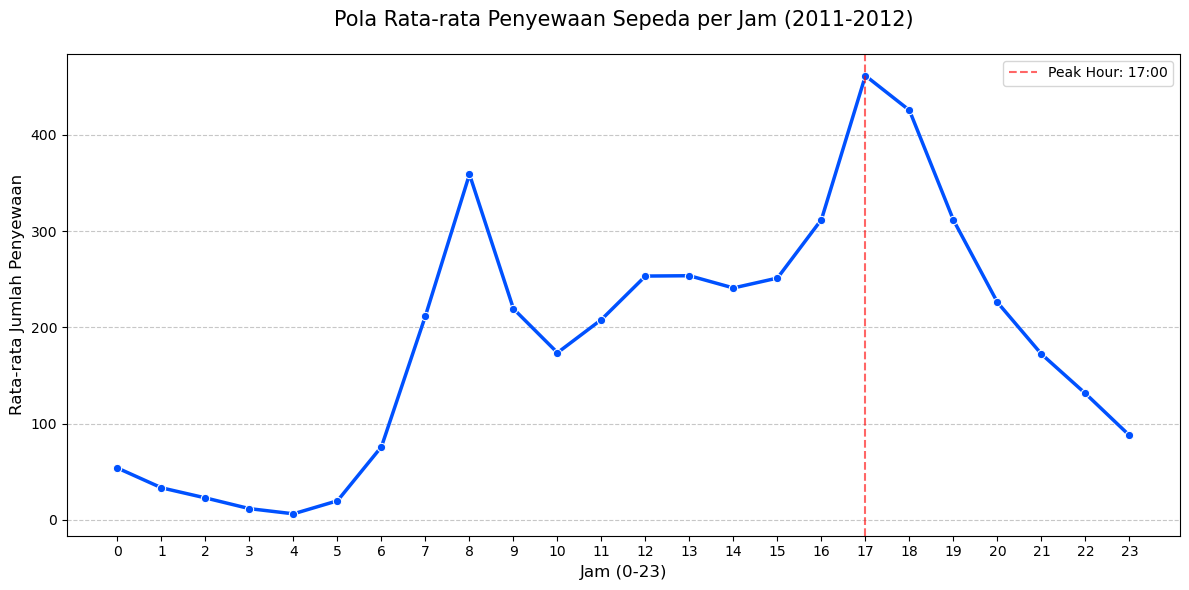

In [45]:
plt.figure(figsize=(12, 6))

# Membuat grafik garis
sns.lineplot(data=hourly_pattern, x='hr', y='cnt', marker='o', color="#0051FF", linewidth=2.5)

# Menambahkan garis bantu untuk menyoroti puncak (Optional tapi membantu)
peak_hour = hourly_pattern.loc[hourly_pattern['cnt'].idxmax(), 'hr']
peak_val = hourly_pattern['cnt'].max()
plt.axvline(x=peak_hour, color='red', linestyle='--', alpha=0.6, label=f'Peak Hour: {peak_hour}:00')

# Mengatur judul dan label
plt.title('Pola Rata-rata Penyewaan Sepeda per Jam (2011-2012)', fontsize=15, pad=20)
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)

# Mengatur skala sumbu X agar muncul semua jam
plt.xticks(range(0, 24))

# Menambah grid untuk kemudahan pembacaan
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

2. Membuat visualisasi bar chart untuk menjawab pertanyaan bisnis 1.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27212\3792030712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_pattern, x='hr', y='cnt', palette=colors)


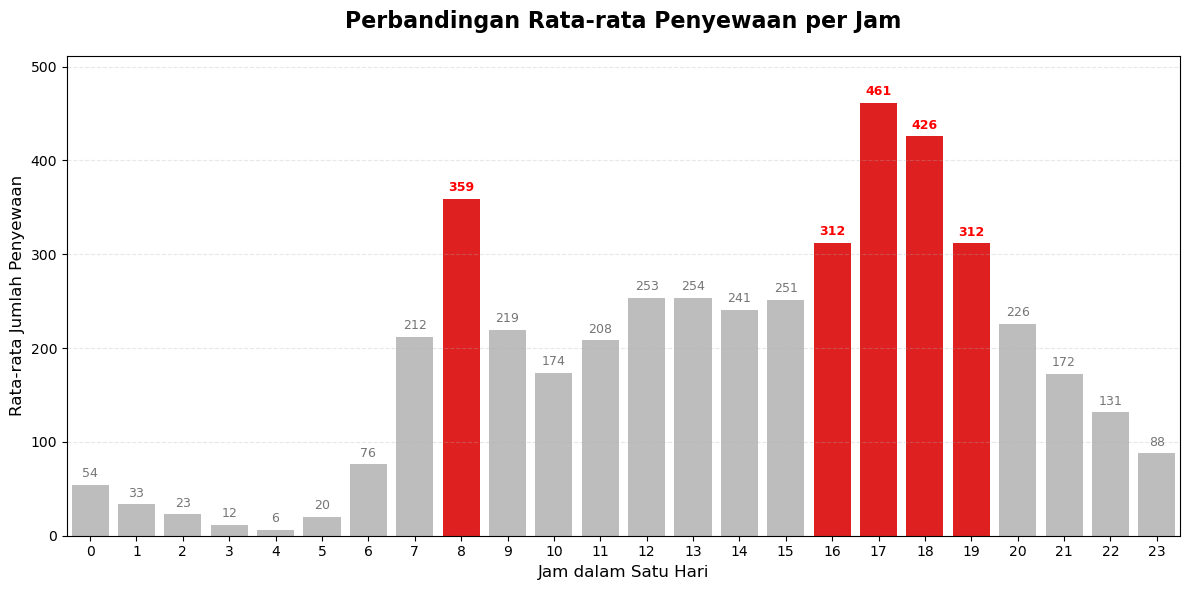

In [46]:
# Menentukan 5 jam tertinggi
top_5_hours = hourly_pattern.nlargest(5, 'cnt')['hr'].tolist()

# Menentukan warna: Merah untuk top 5, Abu-abu untuk sisanya
colors = ["#FF0000" if x in top_5_hours else '#BDBDBD' for x in hourly_pattern['hr']]

# Membuat visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_pattern, x='hr', y='cnt', palette=colors)

# Menambahkan label angka di semua batang
for index, row in hourly_pattern.iterrows():
    hr_val = row['hr']
    cnt_val = row['cnt']
    
    # Tentukan warna teks: Merah jika masuk top 5, Abu-abu jika tidak
    text_color = "#FF0000" if hr_val in top_5_hours else "#757575"
    # Tentukan ketebalan teks: Bold jika masuk top 5
    text_weight = 'bold' if hr_val in top_5_hours else 'normal'
    
    plt.text(
        hr_val, 
        cnt_val + 5, 
        f'{cnt_val:.0f}', 
        ha='center', 
        va='bottom',
        fontweight=text_weight, 
        color=text_color,
        fontsize=9
    )

# Mengatur judul dan label
plt.title('Perbandingan Rata-rata Penyewaan per Jam', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Jam dalam Satu Hari', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)

# Mengatur batas sumbu Y agar teks di atas batang tidak terpotong
plt.ylim(0, hourly_pattern['cnt'].max() + 50)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda per hari selama periode 2011–2012?

1. Membuat visualisasi bar chart untuk menjawab pertanyaan bisnis 2.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27212\1883686208.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[1, 2, 3], y=weather_impact['cnt'], palette=colors)


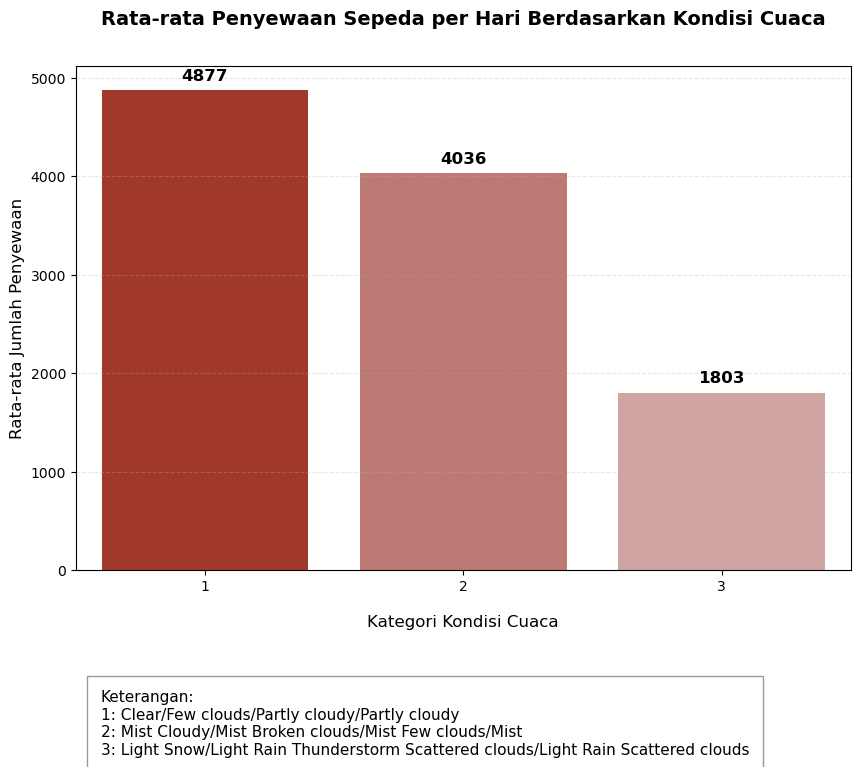

In [47]:
# Definisikan urutan sesuai kategori yang dibuat
urutan_cuaca = [
    'Clear/Few clouds/Partly cloudy/Partly cloudy',
    'Mist Cloudy/Mist Broken clouds/Mist Few clouds/Mist',
    'Light Snow/Light Rain Thunderstorm Scattered clouds/Light Rain Scattered clouds'
]

# Mengubah kolom menjadi tipe categorical agar urutannya terkunci
weather_impact['weathersit'] = pd.Categorical(weather_impact['weathersit'], categories=urutan_cuaca, ordered=True)
weather_impact = weather_impact.sort_values('weathersit')

# 3. Membuat Visualisasi
plt.figure(figsize=(10, 8))

# Warna yang merepresentasikan kondisi cuaca (Cerah, Mendung, Hujan)
colors = ['#B32A19', '#C96E68', '#D89D9A'] 

# Membuat barplot dengan label sumbu X berupa angka 1, 2, 3
sns.barplot(x=[1, 2, 3], y=weather_impact['cnt'], palette=colors)

# Menambahkan label angka presisi di atas setiap batang
for i, val in enumerate(weather_impact['cnt']):
    plt.text(i, val + 100, f'{val:.0f}', ha='center', fontsize=12, fontweight='bold')

# Mengatur Judul dan Label
plt.title('Rata-rata Penyewaan Sepeda per Hari Berdasarkan Kondisi Cuaca', fontsize=14, pad=30, fontweight='bold')
plt.xlabel('Kategori Kondisi Cuaca', fontsize=12, labelpad=15)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)

# Mengatur Sumbu X agar rapi hanya menampilkan angka
plt.xticks([0, 1, 2], [1, 2, 3]) 

# Menambahkan Catatan Keterangan di bagian bawah grafik
keterangan = (
 "Keterangan:\n"
    "1: Clear/Few clouds/Partly cloudy/Partly cloudy\n"
    "2: Mist Cloudy/Mist Broken clouds/Mist Few clouds/Mist\n"
    "3: Light Snow/Light Rain Thunderstorm Scattered clouds/Light Rain Scattered clouds"
)
plt.figtext(0.15, 0.02, keterangan, ha="left", fontsize=11, 
            bbox={"facecolor":"white", "alpha":0.8, "pad":10, "edgecolor":"gray"})

# Memberikan grid halus pada sumbu Y
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Memberikan ruang kosong di bawah agar keterangan tidak terpotong
plt.subplots_adjust(bottom=0.25) 

plt.show()

2. Membuat visualisasi box plot untuk menjawab pertanyaan bisnis 2.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27212\284199276.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


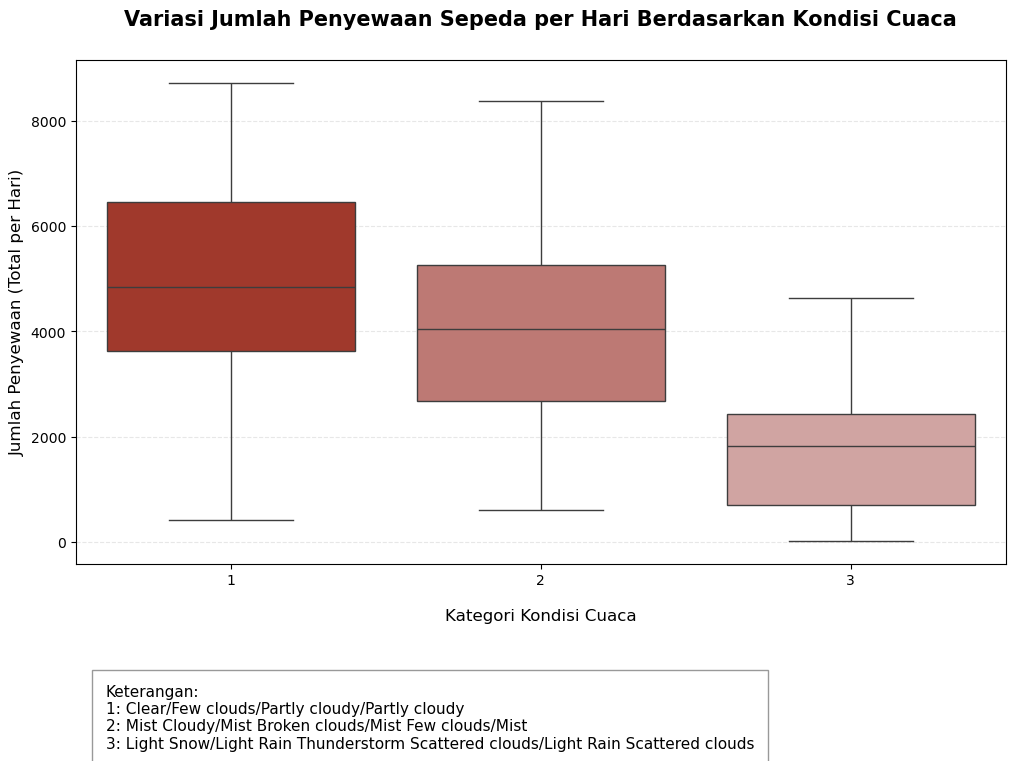

In [48]:
# Buat mapping berdasarkan teks yang ada di dataset 
mapping = {
    'Clear/Few clouds/Partly cloudy/Partly cloudy': 1,
    'Mist Cloudy/Mist Broken clouds/Mist Few clouds/Mist': 2,
    'Light Snow/Light Rain Thunderstorm Scattered clouds/Light Rain Scattered clouds': 3
}

# Terapkan mapping ke kolom baru
df_day['weather_code'] = df_day['weathersit'].map(mapping)

# Membuat visualisasi Box Plot
plt.figure(figsize=(12, 8))

# Gunakan kolom 'weather_code' yang sudah pasti angka 1, 2, 3
sns.boxplot(
    data=df_day, 
    x='weather_code', 
    y='cnt', 
    palette=['#B32A19', '#C96E68', '#D89D9A'] 
)

# Menambah Judul dan Label
plt.title('Variasi Jumlah Penyewaan Sepeda per Hari Berdasarkan Kondisi Cuaca', fontsize=15, pad=25, fontweight='bold')
plt.xlabel('Kategori Kondisi Cuaca', fontsize=12, labelpad=15)
plt.ylabel('Jumlah Penyewaan (Total per Hari)', fontsize=12)

# Mengatur Sumbu X agar tetap 1, 2, 3
plt.xticks([0, 1, 2], [1, 2, 3])

# Menambahkan catatan keterangan
keterangan = (
    "Keterangan:\n"
    "1: Clear/Few clouds/Partly cloudy/Partly cloudy\n"
    "2: Mist Cloudy/Mist Broken clouds/Mist Few clouds/Mist\n"
    "3: Light Snow/Light Rain Thunderstorm Scattered clouds/Light Rain Scattered clouds"
)
plt.figtext(0.15, 0.02, keterangan, ha="left", fontsize=11, 
            bbox={"facecolor":"white", "alpha":0.8, "pad":10, "edgecolor":"gray"})

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.subplots_adjust(bottom=0.25) 

plt.show()

**Insight:**
- Terdapat dua puncak aktivitas yang jelas, yaitu pada jam berangkat kerja (08:00) dan jam pulang kerja (17:00).
- Pukul 17:00 adalah waktu tersibuk dengan rata-rata 461 penyewaan. Hal ini menunjukkan bahwa sepeda banyak digunakan sebagai solusi transportasi.
- Tren menurun secara drastis setelah pukul 20:00 dan mencapai titik terendah pada pukul 04:00 pagi, yang menandakan aktivitas mobilitas warga yang sangat rendah pada jam tersebut.
- Kondisi cuaca memiliki pengaruh terhadap rata-rata jumlah penyewaan sepeda per hari selama periode 2011 - 2012 yang dijelaskan sebagai berikut : cuaca dengan kategori 1 yaitu Clear/Few clouds/Partly cloudy/Partly cloudy adalah kategori cuaca dengan penyewaan tertinggi hingga rata-ratanya mencapai 4877 unit sepeda per hari dan berdasarkan box plot pada kategori ini penyewaan maksimal nya di atas 8000 unit. Lalu cuaca dengan kategori 2 yaitu Mist Cloudy/Mist Broken clouds/Mist Few clouds/Mist masih menunjukkan jumlah rata-rata penyewaan sepeda yang cukup baik yaitu 4036 unit yang menunjukkan bahwa penyewa masih tetap melakukan penyewaan sepeda meskipun cuaca berkabut atau mendung. Lalu pada cuaca dengan kategori 3 yaitu Light Snow/Light Rain Thunderstorm Scattered clouds/Light Rain Scattered clouds terjadi penurunan permintaan penyewaan sepeda yang sangat tajam dengan rata-rata penyewaan per hari nya hanya mencapai 1803 unit hal ini dikarenakan cuacanya yang buruk.
- Pada box plot meskipun rata-ratanya tinggi, Kategori 1 memiliki rentang (interquartile range) yang paling lebar. Ini berarti ada faktor lain (seperti hari kerja vs hari libur) yang membuat jumlah penyewaan di hari cerah bisa sangat fluktuatif. 
- Pada Kategori 3, kotak pada Box Plot terlihat lebih kecil dan berada di area bawah, menandakan bahwa saat hujan, hampir dipastikan jumlah penyewaan akan rendah secara konsisten tanpa banyak anomali.

## Analisis Lanjutan (Opsional)

Analisis lanjutan dilakukan dengan melakukan manual clustering dengan mengelompokkan 24 jam sehari ke dalam segmen waktu berdasarkan aktivitas manusia. Pembagiannya sebagai berikut: 1. Rush Hours (7-9 & 16-18) adalah jam sibuk orang berangkat dan pulang kerja; 2. Business Hours (10-15) adalah jam produktif saat orang sudah sampai di kantor; 3. Evening Leisure (19-23) adalah waktu santai setelah melakukan aktivitas seharian; 4. Rest Time (0-6) adalah waktu istirahat/tidur. Clustering tersebut dilakukan untuk melihat perilaku penyewa sepeda secara makro.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27212\1077054553.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


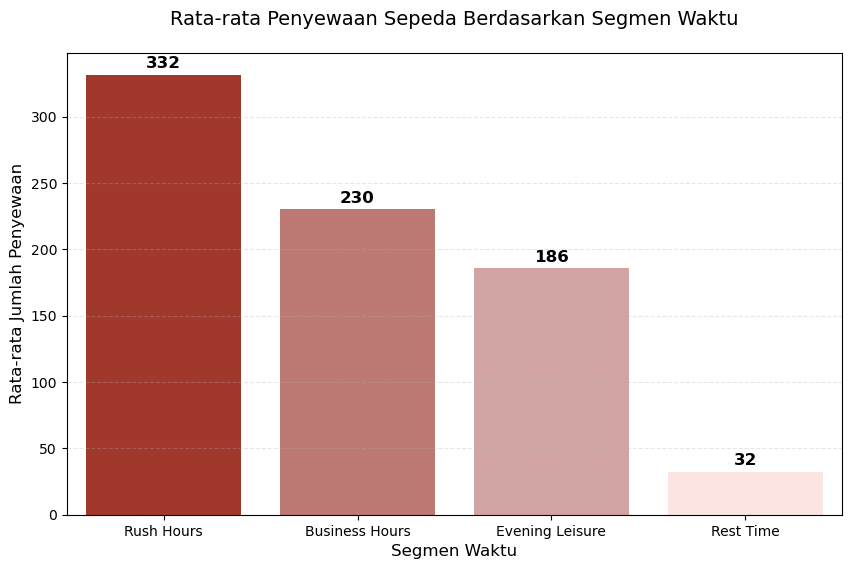

In [49]:
# Definisi fungsi untuk Manual Clustering (Binning berdasarkan Jam)
def hour_clustering(hour):
    if 7 <= hour <= 9 or 16 <= hour <= 18:
        return 'Rush Hours'
    elif 10 <= hour <= 15:
        return 'Business Hours'
    elif 19 <= hour <= 23:
        return 'Evening Leisure'
    else:
        return 'Rest Time'

# Menerapkan clustering ke dalam kolom baru
df_hour['time_segment'] = df_hour['hr'].apply(hour_clustering)

# Menghitung rata-rata penyewaan per segmen waktu untuk visualisasi
segment_analysis = df_hour.groupby('time_segment')['cnt'].mean().reset_index()

# Mengurutkan kategori agar logis secara waktu (Opsional)
mapping_order = {'Rush Hours': 0, 'Business Hours': 1, 'Evening Leisure': 2, 'Rest Time': 3}
segment_analysis['sort_key'] = segment_analysis['time_segment'].map(mapping_order)
segment_analysis = segment_analysis.sort_values('sort_key')

# 4. Membuat Visualisasi
plt.figure(figsize=(10, 6))
colors = ['#B32A19', '#C96E68', '#D89D9A', "#FFE1DE"] 
sns.barplot(
    data=segment_analysis, 
    x='time_segment', 
    y='cnt', 
    palette=colors
)

# Menambahkan label angka di atas batang
for i, val in enumerate(segment_analysis['cnt']):
    plt.text(i, val + 5, f'{val:.0f}', ha='center', fontsize=12, fontweight='bold')

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Segmen Waktu', fontsize=14, pad=20)
plt.xlabel('Segmen Waktu', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

**Insight:**
- Segmen Rush Hours (jam berangkat dan pulang kerja) mencatatkan rata-rata tertinggi sebesar 332 penyewaan. Ini mengonfirmasi bahwa penggunaan utama sepeda adalah sebagai alat transportasi komuter.
- Aktivitas di jam kerja tetap tinggi (230), lebih besar dibandingkan jam santai malam hari (186). Hal ini menunjukkan adanya mobilitas profesional yang signifikan (misalnya kurir atau pekerja yang berpindah lokasi) di siang hari.
- Dengan rata-rata hanya 32 penyewaan, segmen Rest Time adalah waktu yang paling efisien untuk melakukan pengisian ulang stok sepeda (rebalancing) di setiap stasiun dengan gangguan minimal terhadap pengguna.

## Conclusion

Berdasarkan seluruh rangkaian analisis yang telah dilakukan, maka dapat disimpulkan bahwa : 
- Penyewaan sepeda sangat bergantung pada siklus aktivitas harian penduduk. Terdapat korelasi yang sangat kuat antara jam sibuk (Rush Hours) dengan lonjakan penyewaan. Puncak tertinggi yang terjadi pada pukul 17:00 menegaskan bahwa layanan ini bukan sekadar sarana rekreasi, melainkan infrastruktur transportasi vital bagi kaum komuter untuk pulang kerja atau sekolah.
- Faktor cuaca, bertindak sebagai filter utama dalam keputusan pengguna, yaitu saat cuaca cerah merupakan kondisi ideal yang menjamin volume penyewaan maksimal dan saat cuaca buruk (Hujan/Salju) mengakibatkan penurunan permintaan yang drastis (hingga lebih dari 60%). Hal ini menunjukkan adanya keterbatasan fasilitas pelindung bagi pengguna saat kondisi ekstrem, yang menyebabkan mereka beralih ke moda transportasi tertutup.
- Melalui teknik manual clustering, kita berhasil memetakan waktu-waktu kritis, yaitu saat Rush Hours harus memaksimalkan ketersediaan sepeda dan saat Rest Time (tengah malam hingga subuh) adalah waktu untuk melakukan pemeliharaan tanpa mengganggu pendapatan, karena rata-rata penyewaan berada di titik terendah.

Rekomendasi Akhir :
- Perusahaan harus menerapkan sistem Predictive Rebalancing 30 menit sebelum memasuki segmen Rush Hours (pukul 06:30 dan 15:30) dengan  menugaskan tim operasional untuk memindahkan stok sepeda dari area pemukiman ke titik-titik transportasi publik (stasiun/halte) pada pagi hari, dan sebaliknya pada sore hari menuju area perkantoran untuk memastikan ketersediaan unit tetap terjaga di titik-titik dengan permintaan tertinggi sesuai pola commuting yang ditemukan, sehingga tidak ada calon penyewa yang kecewa karena kehabisan sepeda.
- Meluncurkan fitur "Rainy Day Voucher" atau diskon khusus saat kondisi cuaca mendung/hujan ringan (kategori 2 dan 3) dengan memberikan notifikasi otomatis melalui aplikasi berupa potongan harga 20-30% jika sensor cuaca mendeteksi kondisi mendung atau hujan ringan hal ini untuk menstimulasi minat penyewa agar tetap menggunakan sepeda meskipun kondisi cuaca kurang ideal, guna menjaga stabilitas pendapatan harian yang biasanya menurun drastis saat cuaca buruk.

### Merge dataset untuk dashboard

In [50]:
# Samakan format tanggal di kedua dataframe
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
df_day['dteday'] = pd.to_datetime(df_day['dteday'])

# Lakukan Merge
all_df = pd.merge(
    left=df_hour,
    right=df_day,
    how="left", # Memastikan semua data di df_hour tetap ada
    on="dteday",
    suffixes=('_hour', '_day')
)

# CEK DATA 
# Jalankan ini, jika hasilnya > 0 berarti ada data yang tidak sinkron
print(f"Jumlah baris kosong setelah merge: {all_df['weathersit_day'].isna().sum()}")

# Tambahkan kolom clustering
def hour_segment(hr):
    if 7 <= hr <= 9 or 16 <= hr <= 18: return 'Rush Hours'
    elif 10 <= hr <= 15: return 'Business Hours'
    elif 19 <= hr <= 23: return 'Evening Leisure'
    else: return 'Rest Time'

all_df['time_segment'] = all_df['hr'].apply(hour_segment)

# Simpan ke folder dashboard
all_df.to_csv("dashboard/main_data.csv", index=False)

Jumlah baris kosong setelah merge: 0
